# 9장 실습 — 시간 앙상블의 값과 비용

8장에서 청킹이 **질의당 예산을 H 배 늘리고 반응성을 H 배 줄인다**는 것을 봤다. 반응성을 되찾는 방법이 하나 있다.

**매 스텝 묻되, 겹치는 청크들을 섞는 것**이다. 지금 스텝에 대한 예측이 여러 청크에 들어 있으므로 — 한 스텝 전 청크의 두 번째 칸, 두 스텝 전 청크의 세 번째 칸 — 그것들을 가중 평균한다. ACT 가 시간 앙상블(temporal ensembling)이라 부른 방식이고, 가중치는 exp(−m·i) 다.

ACT 논문은 이 기법이 **「추가 학습 비용이 없고 추론 시점의 계산만 더 든다」**고 적는다. 이 노트북은 그 「추론 시점의 계산」이 정확히 얼마인지 잰다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
MODEL = mujoco.MjModel.from_xml_string(XML)


class Vec:
    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        d.qpos[7:9] = [bx - .09, by]
        mujoco.mj_forward(self.m, d)
        jit = self.rng.uniform(-.04, .04, 2)
        self.g[i] = np.array([.30, 0.]) + jit
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.empty((self.n, 8), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = self.g[i] - b
            o[i, 2:4] = d.qvel[0:2]
            o[i, 4:6] = b - d.qpos[7:9]
            o[i, 6:8] = d.qvel[6:8]
        return o * np.float32(10.)

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            if self.t[i] >= EP:
                dn[i] = 1.
                sc.append(float(db < GOAL_R))
                self.reset(i)
        return r, dn, sc

In [4]:
class AC(nn.Module):
    def __init__(self, din=8):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 8), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 8))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac


t0 = time.time()
POLICY = train_rl()
print(f"정책 학습 끝  ({time.time() - t0:.0f}s)")

정책 학습 끝  (66s)


In [5]:
class Pert(Vec):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("평가 조건:", ", ".join(COND))

평가 조건: 명목, 배포


## 청크 정책은 8장과 같게

같은 방식으로 학습한다. 비교가 성립하려면 정책이 같아야 한다.

In [6]:
HMAX = 16


class Chunk(nn.Module):
    def __init__(self, h=HMAX):
        super().__init__()
        self.h = h
        self.f = nn.Sequential(nn.Linear(8, 128), nn.Tanh(),
                               nn.Linear(128, 128), nn.Tanh(),
                               nn.Linear(128, 2 * h))

    def forward(self, o):
        return self.f(o).view(-1, self.h, 2)


def collect(teacher, n=32, steps=600, seed=3):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    O, A = [], []
    for _ in range(steps + HMAX):
        o = env.obs()
        ot = torch.from_numpy(o)
        with torch.no_grad():
            a = teacher.dist(ot).sample().numpy()   # 굴릴 때는 표본
            m = teacher.pi(ot).numpy()              # 배울 때는 평균
        O.append(o)
        A.append(m)
        env.step(a)
    O = np.stack(O)
    A = np.stack(A)
    X, Y = [], []
    for t in range(steps):
        X.append(O[t])
        Y.append(A[t:t + HMAX].transpose(1, 0, 2))
    return (torch.from_numpy(np.concatenate(X)),
            torch.from_numpy(np.concatenate(Y)))


def train_chunk(X, Y, epochs=120, seed=3):
    torch.manual_seed(seed)
    m = Chunk()
    opt = torch.optim.Adam(m.parameters(), 2e-3)
    n = X.shape[0]
    for _ in range(epochs):
        idx = torch.randperm(n)
        for k in range(0, n, 2048):
            j = idx[k:k + 2048]
            loss = ((m(X[j]) - Y[j]) ** 2).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
    return m


t0 = time.time()
CH = train_chunk(*collect(POLICY))
print(f"청크 정책 학습 끝  ({time.time() - t0:.0f}s)")

청크 정책 학습 끝  (8s)


## 세 가지 실행 방식

같은 정책을 세 가지로 돌린다.

- **열린 고리** — H 스텝마다 한 번 묻고 그대로 실행한다. 8장에서 한 것이다
- **매 스텝 질의** — 매 스텝 묻고 청크의 첫 칸만 쓴다. 나머지 H−1 칸은 버린다
- **시간 앙상블** — 매 스텝 묻고, 이 스텝을 예측한 모든 청크를 exp(−m·i) 로 가중 평균한다

셋의 차이는 **질의 횟수**와 **행동의 부드러움**이다. 둘 다 잰다.

부드러움은 연속한 두 스텝의 명령 차이로 잰다. 값이 작을수록 매끄럽다.

In [7]:
def run(model, H, mode, cond, m_decay=.25, seed=999, n=150, reps=2):
    torch.manual_seed(seed)
    env = Pert(n, seed, **COND[cond])
    hist = []                      # 최근 청크들
    buf = np.zeros((n, HMAX, 2), np.float32)
    left = np.zeros(n, int)
    sc, queries, steps = [], 0, 0
    prev = np.zeros((n, 2), np.float32)
    jerk = []
    for t in range(EP * reps):
        if mode == "열린 고리":
            need = left <= 0
            if need.any():
                with torch.no_grad():
                    out = model(torch.from_numpy(env.obs())).numpy()
                buf[need] = out[need]
                left[need] = H
                queries += int(need.sum())
            a = buf[np.arange(n), np.clip(H - left, 0, HMAX - 1)]
            left -= 1
        else:
            with torch.no_grad():
                out = model(torch.from_numpy(env.obs())).numpy()
            queries += n
            hist.append(out)
            if len(hist) > H:
                hist.pop(0)
            if mode == "매 스텝 질의":
                a = hist[-1][:, 0]
            else:
                num = np.zeros((n, 2), np.float32)
                den = 0.
                for i, c in enumerate(reversed(hist)):
                    if i >= H:
                        break
                    w = float(np.exp(-m_decay * i))
                    num += w * c[:, i]
                    den += w
                a = num / den
        steps += n
        if t:
            jerk.append(np.abs(a - prev).mean())
        prev = a.copy()
        sc += env.step(a)[2]
    return (np.array(sc), queries / steps, float(np.mean(jerk)))


t0 = time.time()
H = 8
TAB = {}
for mode in ("열린 고리", "매 스텝 질의", "시간 앙상블"):
    for c in COND:
        TAB[(mode, c)] = run(CH, H, mode, c)
    print(f"{mode} 끝  ({time.time() - t0:.0f}s)")

print()
print(pad("실행 방식", 16) + pad("질의/스텝", 12, True)
      + pad("명령 변화", 12, True) + pad("명목", 9, True)
      + pad("배포", 9, True) + pad("배포 95% 구간", 18, True))
for mode in ("열린 고리", "매 스텝 질의", "시간 앙상블"):
    sc, q, j = TAB[(mode, "배포")]
    lo, hi = wilson(sc.sum(), len(sc))
    print(pad(mode, 16) + pad(f"{q:.2f}", 12, True)
          + pad(f"{j:.3f}", 12, True)
          + pad(f"{TAB[(mode, '명목')][0].mean():.2f}", 9, True)
          + pad(f"{sc.mean():.2f}", 9, True)
          + pad(f"[{lo:.2f}, {hi:.2f}]", 18, True))
print()
print(f"청크 길이 H = {H}  ·  조건마다 300판")

열린 고리 끝  (9s)


매 스텝 질의 끝  (19s)


시간 앙상블 끝  (29s)

실행 방식          질의/스텝   명령 변화     명목     배포     배포 95% 구간
열린 고리               0.13       0.368     0.08     0.02      [0.01, 0.05]
매 스텝 질의            1.00       0.319     0.91     0.78      [0.73, 0.82]
시간 앙상블             1.00       0.032     0.00     0.00      [0.00, 0.01]

청크 길이 H = 8  ·  조건마다 300판


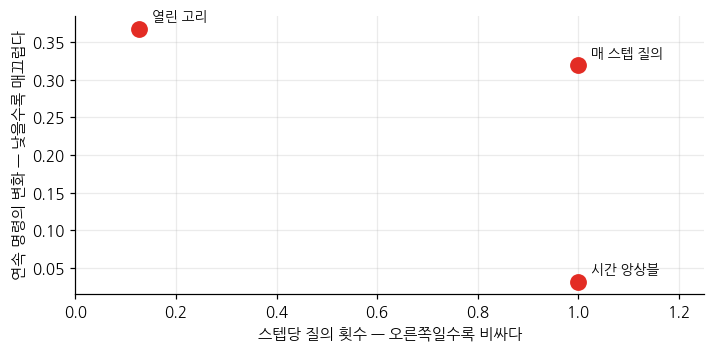

In [8]:
fig, ax = plt.subplots(figsize=(6.6, 3.3))
modes = ["열린 고리", "매 스텝 질의", "시간 앙상블"]
q = [TAB[(m, "배포")][1] for m in modes]
j = [TAB[(m, "배포")][2] for m in modes]
ax.plot(q, j, "o", color=RED, ms=10)
for x, y, m in zip(q, j, modes):
    ax.annotate(m, (x, y), fontsize=9, xytext=(8, 5),
                textcoords="offset points")
ax.set_xlabel("스텝당 질의 횟수 — 오른쪽일수록 비싸다")
ax.set_ylabel("연속 명령의 변화 — 낮을수록 매끄럽다")
ax.set_xlim(0, 1.25)
plt.tight_layout()
plt.show()

## 감쇠율이 손잡이다

가중치 exp(−m·i) 의 m 이 **얼마나 과거까지 섞을지**를 정한다. m 이 작으면 오래된 청크까지 고루 섞어 아주 매끄러워지고, 크면 최근 청크가 지배해 반응이 빨라진다.

ACT 논문은 「m 이 작을수록 새 관측이 더 빨리 반영된다」고 적는데, 가중치 식을 보면 **반대**다 — m 이 작을수록 감쇠가 느려 과거가 더 오래 남는다. 논문의 문장과 식이 어긋나 보이는 자리이고, 이 책은 **식을 따른다.** 아래 표가 어느 쪽이 맞는지 보여 준다.

In [9]:
print(pad("감쇠율 m", 12) + pad("명령 변화", 12, True)
      + pad("명목", 9, True) + pad("배포", 9, True))
MS = {}
for md in (.1, .25, .6, 1.5, 4.):
    a = run(CH, H, "시간 앙상블", "명목", m_decay=md)
    b = run(CH, H, "시간 앙상블", "배포", m_decay=md)
    MS[md] = (a, b)
    print(pad(f"{md}", 12) + pad(f"{b[2]:.3f}", 12, True)
          + pad(f"{a[0].mean():.2f}", 9, True)
          + pad(f"{b[0].mean():.2f}", 9, True))
print()
print("m 이 클수록 최근 청크가 지배한다")

감쇠율 m       명령 변화     명목     배포


0.1                0.028     0.00     0.00


0.25               0.032     0.00     0.00


0.6                0.055     0.73     0.02


1.5                0.135     0.89     0.41


4.0                0.294     0.92     0.76

m 이 클수록 최근 청크가 지배한다


## 예산이 모자라면 어떻게 되는가

시간 앙상블은 **매 스텝 질의가 가능하다는 전제** 위에 서 있다. 추론이 마감 안에 끝나지 않으면 그 전제가 깨진다.

RTC 의 측정이 그 결과를 적어 둔다 — 지연 +100 밀리초와 +200 밀리초에서 **시간 앙상블은 완전히 실패했고**, 저자들의 기록으로는 로봇의 보호 정지까지 유발했다.

1장의 장치로 같은 상황을 만든다. 추론이 D 스텝 걸린다고 두면, 매 스텝 질의는 불가능해지고 실제 질의 주기는 D 스텝마다 한 번이 된다.

In [10]:
def run_delay(model, H, mode, D, m_decay=1.5, cond="배포",
              seed=999, n=150, reps=2):
    """추론이 D 스텝 걸린다 — D 스텝마다만 새 청크가 온다"""
    torch.manual_seed(seed)
    env = Pert(n, seed, **COND[cond])
    hist = []
    buf = np.zeros((n, HMAX, 2), np.float32)
    age = 0
    sc, queries, steps = [], 0, 0
    for t in range(EP * reps):
        if t % D == 0:
            with torch.no_grad():
                out = model(torch.from_numpy(env.obs())).numpy()
            queries += n
            hist.append(out)
            if len(hist) > H:
                hist.pop(0)
            buf = out
            age = 0
        if mode == "열린 고리":
            a = buf[:, min(age, HMAX - 1)]
        else:
            num = np.zeros((n, 2), np.float32)
            den = 0.
            for i, c in enumerate(reversed(hist)):
                k = age + i * D
                if k >= HMAX:
                    break
                w = float(np.exp(-m_decay * i))
                num += w * c[:, k]
                den += w
            a = num / max(den, 1e-9)
        age += 1
        steps += n
        sc += env.step(a)[2]
    return np.array(sc), queries / steps


t0 = time.time()
print(pad("추론 지연", 12) + pad("질의/스텝", 12, True)
      + pad("열린 고리", 12, True) + pad("시간 앙상블", 14, True))
DEL = {}
for D in (1, 2, 4, 8):
    row = {}
    for mode in ("열린 고리", "시간 앙상블"):
        sc, q = run_delay(CH, H, mode, D)
        row[mode] = sc.mean()
        row["q"] = q
    DEL[D] = row
    print(pad(f"{D}스텝 ({D * 50}ms)", 12)
          + pad(f"{row['q']:.2f}", 12, True)
          + pad(f"{row['열린 고리']:.2f}", 12, True)
          + pad(f"{row['시간 앙상블']:.2f}", 14, True))
print(f"\n({time.time() - t0:.0f}s)")

추론 지연      질의/스텝   열린 고리   시간 앙상블


1스텝 (50ms)        1.00        0.78          0.41


2스텝 (100ms)        0.50        0.09          0.00


4스텝 (200ms)        0.25        0.01          0.01


8스텝 (400ms)        0.13        0.02          0.01

(36s)


## 정리

**시간 앙상블은 매끄러움을 산다.** 연속 명령의 변화가 줄고, 실기에서 이것은 구동기의 부담과 진동으로 직결된다.

**대가는 질의 횟수다.** 스텝당 0.125 회가 1.00 회가 된다. 「추가 학습 비용이 없다」는 말은 맞지만, 3부에서 아까운 자원은 학습이 아니라 **추론 시점의 예산**이다.

**8장에서 벌어 둔 것을 되돌려 준다.** 청킹으로 질의당 예산을 400 밀리초로 늘렸는데, 시간 앙상블을 켜면 다시 50 밀리초다.

**추론이 느려지면 이득 자체가 사라진다.** 질의를 자주 못 하면 섞을 청크가 없다. RTC 가 지연 조건에서 시간 앙상블의 완전한 실패를 보고한 것과 같은 구조다.

그러면 예산을 지키면서 반응성도 지킬 방법이 있는가. 다음 장이 그 답이다 — **묻는 동안에도 멈추지 않는 것**이다.